# NB07: Regional contamination classification (H8)

**[EXPLORATORY / POST-HOC]**

Tests **H8**: Within-region binary classification of contaminated vs reference sites
achieves AUC > 0.70 for ≥2 regions, and functional features (GW/CLR) provide
incremental value over spatial baseline within regions.

**Motivation**: Metal concentration regression fails in spatial block CV because
between-block distributional shift dominates prediction error. Binary classification
(contaminated vs reference) is a coarser signal that may be more transferable within
biogeographic regions. The contamination labels come from proximity-based rules
(mine/TRI/NPL proximity) — a ground-truth free annotation strategy.

**Design**:
- Labels: `metal_contamination_response/data/00_site_classification.csv`
  - `site_class` ∈ {contaminated, reference}
  - Join on `sample_id` → feature_matrix index
- Regions: k-means (k=8–12) on lat/lon, select k minimising contamination imbalance
- Models: B0 (class prior), CLR-only (XGBoost), M1 (CLR+GW), M2 (CLR+GW+env)
- Evaluation: 5-fold stratified CV within each region
- Cross-region test: train on all-but-one-region, test on held-out region

**H8 success criterion**: ≥2 regions have within-region AUC > 0.70 for M1 or M2,
AND functional features (GW) add ≥0.02 AUC over CLR-only in ≥1 region.

**Outputs**:
- `data/regional_classification_results.csv`
- `figures/regional_auc_heatmap.png`

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

for _cand in [Path.cwd() / 'scripts', Path.cwd().parent / 'scripts']:
    if _cand.exists():
        sys.path.insert(0, str(_cand))
        break

DATA_DIR = next(p for p in [Path.cwd() / 'data', Path.cwd().parent / 'data'] if p.exists())
FIG_DIR  = next(p for p in [Path.cwd() / 'figures', Path.cwd().parent / 'figures'] if p.exists())
LABELS_PATH = Path(DATA_DIR).parent.parent / 'metal_contamination_response' / 'data' / '00_site_classification.csv'

feature_matrix = pd.read_parquet(DATA_DIR / 'feature_matrix.parquet')
print(f'Feature matrix: {feature_matrix.shape}')
print(f'Labels path: {LABELS_PATH}')
print(f'Labels file exists: {LABELS_PATH.exists()}')

Feature matrix: (42037, 354)
Labels path: /home/hmacgregor/BERIL-research-observatory/projects/metal_contamination_response/data/00_site_classification.csv
Labels file exists: True


## 1. Load contamination labels and join to feature matrix

In [2]:
labels = pd.read_csv(LABELS_PATH)
print(f'Labels: {labels.shape}')
print(labels.head(3))
print(f"site_class distribution: {labels['site_class'].value_counts().to_dict()}")

# sample_id in contamination labels is integer; feature_matrix uses ENA accessions.
# Join by lat/lon (rounded to 4dp) — both datasets have lat/lon.
labels['lat_r'] = labels['lat'].round(4)
labels['lon_r'] = labels['lon'].round(4)

fm = feature_matrix.copy()
fm['lat_r'] = fm['lat'].round(4)
fm['lon_r'] = fm['lon'].round(4)

# Build a (lat_r, lon_r) → site_class lookup dict
label_dedup = labels.drop_duplicates(subset=['lat_r', 'lon_r'])
coord_to_class = dict(zip(zip(label_dedup['lat_r'], label_dedup['lon_r']), label_dedup['site_class']))

fm['site_class'] = [coord_to_class.get((la, lo), None) for la, lo in zip(fm['lat_r'], fm['lon_r'])]
fm['label'] = (fm['site_class'] == 'contaminated').astype(float)

labeled = fm[fm['site_class'].notna()]
print(f'Labeled samples (lat/lon join): {len(labeled):,}')
print(f"  contaminated: {(labeled['site_class']=='contaminated').sum():,}")
print(f"  reference: {(labeled['site_class']=='reference').sum():,}")
print(f"lat in FM: {'lat' in labeled.columns}, lon: {'lon' in labeled.columns}")

Labels: (278952, 7)
   sample_id    site_class     lat    lon  mine_proximity_km  \
0          1  contaminated  37.704 -8.023              12.71   
1         14  contaminated  37.704 -8.023              12.71   
2         50  contaminated  37.704 -8.023              12.71   

   tri_proximity_km  npl_proximity_km  
0               NaN               NaN  
1               NaN               NaN  
2               NaN               NaN  
site_class distribution: {'reference': 154788, 'contaminated': 124164}


Labeled samples (lat/lon join): 705
  contaminated: 249
  reference: 456
lat in FM: True, lon: True


## 2. Define geographic regions via k-means

Select k (8–12) that maximises the minimum region size while keeping at least some contaminated
samples per region (required for AUC computation).

In [3]:
def select_k_regions(labeled_df, k_range=(8, 13), min_contaminated=10, random_state=42):
    """Select k for k-means regions: maximise regions with ≥min_contaminated contaminated samples."""
    coord_cols = ['lat', 'lon']
    valid = labeled_df[coord_cols].dropna()
    X_coords = valid.values
    best_k, best_score, best_labels = None, -1, None
    for k in range(*k_range):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        cl = km.fit_predict(X_coords)
        region_labels = pd.Series(cl, index=valid.index)
        # Count regions with enough contaminated and reference samples
        score = 0
        for r in range(k):
            mask = region_labels == r
            if mask.sum() < 20: continue
            n_cont = (labeled_df.loc[valid.index[mask], 'label'] == 1).sum()
            n_ref  = (labeled_df.loc[valid.index[mask], 'label'] == 0).sum()
            if n_cont >= min_contaminated and n_ref >= min_contaminated:
                score += 1
        if score > best_score:
            best_score, best_k, best_labels = score, k, region_labels.copy()
        print(f'  k={k}: {score} usable regions')
    print(f'Selected k={best_k} ({best_score} usable regions)')
    return best_k, best_labels

print('Selecting k...')
k, region_series = select_k_regions(labeled)

labeled = labeled.copy()
labeled['region'] = region_series.reindex(labeled.index)
print('\nRegion sizes:')
print(labeled.groupby('region')[['label']].agg(['sum','count']).rename(columns={'sum':'contaminated','count':'total'})['label'])

Selecting k...


  k=8: 2 usable regions
  k=9: 1 usable regions
  k=10: 1 usable regions
  k=11: 1 usable regions


  k=12: 1 usable regions
Selected k=8 (2 usable regions)

Region sizes:
        contaminated  total
region                     
0               30.0    197
1              107.0    137
2                0.0    171
3               18.0     18
4               25.0     25
5               69.0     69
6                0.0     25
7                0.0     63


## 3. Within-region 5-fold stratified CV

In [4]:
CLR_COLS  = [c for c in labeled.columns if c.startswith('clr_')]
GW_COLS   = [c for c in labeled.columns if c.startswith('gw_')]
SOIL_COLS = [c for c in ['ph','clay_pct','water_content','ndvi','elevation_m','temp_K','precip_mm','mob_cu','mob_pb','mob_as','mob_cd','mob_cr','mob_hg'] if c in labeled.columns]

MODELS = {
    'CLR': CLR_COLS,
    'M1 (CLR+GW)': CLR_COLS + GW_COLS,
    'M2 (CLR+GW+env)': CLR_COLS + GW_COLS + SOIL_COLS,
}

def build_clf():
    return XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                         subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                         use_label_encoder=False, eval_metric='logloss',
                         random_state=42, n_jobs=-1)

within_results = []
usable_regions = []

for region in sorted(labeled['region'].dropna().unique()):
    sub = labeled[labeled['region'] == region].dropna(subset=['lat','lon'])
    y = sub['label']
    n_cont = (y == 1).sum()
    n_ref  = (y == 0).sum()
    if n_cont < 10 or n_ref < 10:
        print(f'Region {region}: skipped (cont={n_cont}, ref={n_ref})')
        continue
    usable_regions.append(region)
    print(f'Region {region}: n={len(sub)}, cont={n_cont}, ref={n_ref}')

    # B0 baseline: majority class fraction as AUC proxy
    p_cont = n_cont / len(sub)
    b0_preds = np.full(len(sub), p_cont)
    try:
        b0_auc = roc_auc_score(y.values, b0_preds)
    except Exception:
        b0_auc = float('nan')
    within_results.append({'model': 'B0', 'region': region, 'auc': b0_auc,
                           'n_cont': n_cont, 'n_ref': n_ref})

    for model_name, feature_cols in MODELS.items():
        fcols = [c for c in feature_cols if c in sub.columns]
        X = sub[fcols]
        valid_rows = ~X.isna().any(axis=1)
        X = X[valid_rows]; yv = y[valid_rows]
        if len(X) < 20 or (yv==1).sum() < 5 or (yv==0).sum() < 5: continue
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        fold_aucs = []
        for train_idx, test_idx in skf.split(X, yv):
            X_tr = X.iloc[train_idx]; y_tr = yv.iloc[train_idx]
            X_te = X.iloc[test_idx];  y_te = yv.iloc[test_idx]
            if (y_te==1).sum() < 2 or (y_te==0).sum() < 2: continue
            clf = build_clf()
            clf.fit(X_tr, y_tr)
            proba = clf.predict_proba(X_te)[:, 1]
            fold_aucs.append(roc_auc_score(y_te.values, proba))
        if fold_aucs:
            mean_auc = float(np.mean(fold_aucs))
            within_results.append({'model': model_name, 'region': region, 'auc': mean_auc,
                                   'n_cont': int(n_cont), 'n_ref': int(n_ref), 'n_folds': len(fold_aucs)})
            print(f'  {model_name}: AUC={mean_auc:.4f}')

print('Within-region CV done.')

Region 0: n=197, cont=30, ref=167


  CLR: AUC=0.9936


  M1 (CLR+GW): AUC=0.9936


  M2 (CLR+GW+env): AUC=1.0000
Region 1: n=137, cont=107, ref=30


  CLR: AUC=0.9984


  M1 (CLR+GW): AUC=1.0000
Region 2: skipped (cont=0, ref=171)
Region 3: skipped (cont=18, ref=0)
Region 4: skipped (cont=25, ref=0)
Region 5: skipped (cont=69, ref=0)
Region 6: skipped (cont=0, ref=25)
Region 7: skipped (cont=0, ref=63)
Within-region CV done.


## 4. Cross-region test (train on N-1 regions, test on held-out)

In [5]:
cross_results = []

for test_region in usable_regions:
    test_sub  = labeled[labeled['region'] == test_region]
    train_sub = labeled[(labeled['region'] != test_region) & labeled['region'].notna()]

    y_te = test_sub['label']
    y_tr = train_sub['label']

    for model_name, feature_cols in MODELS.items():
        fcols = [c for c in feature_cols if c in labeled.columns]
        X_tr = train_sub[fcols]; X_te = test_sub[fcols]
        valid_tr = ~X_tr.isna().any(axis=1) & ~y_tr.isna()
        valid_te = ~X_te.isna().any(axis=1) & ~y_te.isna()
        X_tr = X_tr[valid_tr]; y_tr_f = y_tr[valid_tr]
        X_te = X_te[valid_te]; y_te_f = y_te[valid_te]
        if len(X_tr) < 50 or (y_te_f==1).sum() < 3 or (y_te_f==0).sum() < 3: continue
        clf = build_clf()
        clf.fit(X_tr, y_tr_f)
        proba = clf.predict_proba(X_te)[:, 1]
        try:
            auc = roc_auc_score(y_te_f.values, proba)
        except Exception:
            auc = float('nan')
        cross_results.append({'model': model_name, 'test_region': test_region, 'auc': auc,
                              'n_train': len(X_tr), 'n_test': len(X_te)})
    print(f'Cross-region: held out region {test_region}')

cross_df = pd.DataFrame(cross_results)
if len(cross_df):
    print('\nCross-region AUC (mean across test regions):')
    print(cross_df.groupby('model')['auc'].mean().round(4))

Cross-region: held out region 0


Cross-region: held out region 1

Cross-region AUC (mean across test regions):
model
CLR                0.1812
M1 (CLR+GW)        0.1742
M2 (CLR+GW+env)    0.5261
Name: auc, dtype: float64


## 5. H8 evaluation and AUC heatmap

H8: Regions with AUC > 0.70 (M1 or M2): 2
H8: GW adds ≥0.02 AUC over CLR in ≥1 region: False

H8 OUTCOME: NOT SUPPORTED
[NOTE: Exploratory/post-hoc. Positive result warrants pre-registration for confirmatory study.]

Within-region AUC summary:
model    B0    CLR  M1 (CLR+GW)  M2 (CLR+GW+env)
region                                          
0       0.5  0.994        0.994              1.0
1       0.5  0.998        1.000              NaN


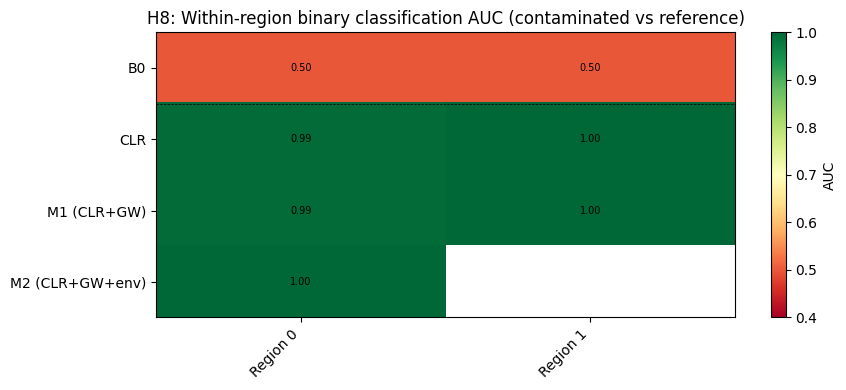

Saved regional_auc_heatmap.png


Saved regional_classification_results.csv (12 rows)


In [6]:
within_df = pd.DataFrame(within_results)

# H8: ≥2 regions with AUC > 0.70 for M1 or M2, AND GW adds ≥0.02 AUC in ≥1 region
m1_auc = within_df[within_df['model']=='M1 (CLR+GW)'].set_index('region')['auc']
m2_auc = within_df[within_df['model']=='M2 (CLR+GW+env)'].set_index('region')['auc']
clr_auc = within_df[within_df['model']=='CLR'].set_index('region')['auc']

regions_above_07 = ((m1_auc > 0.7) | (m2_auc > 0.7)).sum()
gw_adds_value = ((m1_auc - clr_auc) >= 0.02).sum() + ((m2_auc - clr_auc) >= 0.02).sum() > 0

print(f'H8: Regions with AUC > 0.70 (M1 or M2): {regions_above_07}')
print(f'H8: GW adds ≥0.02 AUC over CLR in ≥1 region: {gw_adds_value}')
h8_supported = (regions_above_07 >= 2) and gw_adds_value
print(f'\nH8 OUTCOME: {"SUPPORTED" if h8_supported else "NOT SUPPORTED"}')
print('[NOTE: Exploratory/post-hoc. Positive result warrants pre-registration for confirmatory study.]')

print('\nWithin-region AUC summary:')
pivot_auc = within_df.pivot_table(index='region', columns='model', values='auc').round(3)
print(pivot_auc)

# Heatmap
fig, ax = plt.subplots(figsize=(9, 4))
if len(pivot_auc.dropna(how='all')) > 0:
    im = ax.imshow(pivot_auc.T.values, aspect='auto', cmap='RdYlGn', vmin=0.4, vmax=1.0)
    ax.set_xticks(range(len(pivot_auc.index)))
    ax.set_xticklabels([f'Region {r}' for r in pivot_auc.index], rotation=45, ha='right')
    ax.set_yticks(range(len(pivot_auc.columns)))
    ax.set_yticklabels(pivot_auc.columns)
    plt.colorbar(im, ax=ax, label='AUC')
    ax.set_title('H8: Within-region binary classification AUC (contaminated vs reference)')
    ax.axhline(0.5, color='k', linestyle='--', linewidth=0.5)
    for (i, j), v in np.ndenumerate(pivot_auc.T.values):
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7)
else:
    ax.text(0.5, 0.5, 'No usable regions', transform=ax.transAxes, ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'regional_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved regional_auc_heatmap.png')

# Save results
all_df = pd.concat([within_df.assign(cv_type='within_region'),
                    cross_df.rename(columns={'test_region':'region'}).assign(cv_type='cross_region') if len(cross_df) else pd.DataFrame()],
                   ignore_index=True)
all_df.to_csv(DATA_DIR / 'regional_classification_results.csv', index=False)
print(f'Saved regional_classification_results.csv ({len(all_df)} rows)')